# **ESPIDAM: Best-of-m Bandits on the School Outbreak Environment**
***Authors: Prof. dr. Pieter Libin, Prof. dr. Niel Hens.*** </br>
***Acknowledgments: Bram Silue.*** 

### **How to Run**
If you're having trouble running this code on your local machine, please open and run this notebook in Colab:

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/plibin/espidam-26/blob/main/school-bandit/2_school-exp.ipynb)

We define some helper code that allows this notebook to run in both local environments and Google Colab:

In [1]:
import os
import urllib.request

def is_running_in_colab() -> bool:
    """
    Returns if the code is running inside Google Colab.

    """
    try:
        import google.colab
        return True
    except ImportError:
        return False

def download_file(filepath: str,
                  url: str) -> None:
    """
    Download a file from a URL if it does not exist locally. This is only
    performed when running inside Google Colab.

    Arguments
    ---------
    filepath :  The local path (including subdirectories) where the file should be saved.
    url      :  The direct URL to download the file from.

    """
    if is_running_in_colab() and not os.path.exists(filepath):
        os.makedirs(os.path.dirname(filepath) or '.', exist_ok=True)
        print(f"Downloading {filepath} from {url}")
        urllib.request.urlretrieve(url, filepath)

# Base URL for downloading the `bfts` package files from GitHub when running on Colab.
BASE_URL = "https://raw.githubusercontent.com/plibin/espidam-26/main/school-bandit/"

For Colab runs, we download the necessary files (i.e., the `bfts` package and the precomputed reward data):

In [2]:
# The experiments rely on the `bfts` package (the bandit algorithms,
# environments and posteriors). When running locally these files already
# sit next to this notebook; on Colab we download them from GitHub.
bfts_files = [
    "import_bfts.py",
    "bfts/__init__.py",
    "bfts/bandit.py",
    "bfts/run_utils.py",
    "bfts/run_atlucb.py",
    "bfts/run_uniform.py",
    "bfts/run_bfts.py",
    "bfts/postprocess.py",
    "bfts/algorithms/__init__.py",
    "bfts/algorithms/uniform.py",
    "bfts/algorithms/atlucb.py",
    "bfts/algorithms/bfts.py",
    "bfts/algorithms/posteriors/__init__.py",
    "bfts/algorithms/posteriors/beta.py",
    "bfts/algorithms/posteriors/t_distribution.py",
    "bfts/algorithms/posteriors/truncated_t_distribution.py",
    "bfts/algorithms/posteriors/gaussian.py",
    "bfts/algorithms/posteriors/truncated_gaussian.py",
    "bfts/algorithms/posteriors/gamma.py",
    "bfts/algorithms/posteriors/dirichlet.py",
    "bfts/environments/__init__.py",
    "bfts/environments/bernoulli.py",
    "bfts/environments/csv_dist.py",
    "bfts/environments/gaussian_jun.py",
    "bfts/environments/gaussian_jun_lin_var.py",
    "bfts/environments/captions_jun.py",
    "bfts/environments/poisson_olivier.py",
    "bfts/environments/poisson_exp.py",
    "bfts/environments/scaled_gaussian.py",
    "bfts/plot/merge_results.py",
    "bfts/plot/plot.py",
    "brute-force-reward.csv",
]

if is_running_in_colab():
    for rel_path in bfts_files:
        download_file(rel_path, BASE_URL + rel_path)

### **Introduction**
A **multi-armed bandit** is a sequential decision problem: at every time step we choose one of $n$ *arms*, pull it, and observe a noisy reward drawn from that arm's (unknown) reward distribution. Here we are interested in the **$m$-top identification** problem, where the goal is not to maximise the cumulative reward, but to identify the set of $m$ arms with the highest mean reward as quickly and reliably as possible.

We compare three strategies for selecting which arms to sample:

- **Uniform** &mdash; a simple baseline that repeatedly samples the least-sampled arms.
- **AT-LUCB** &mdash; an *anytime* version of the LUCB (Lower-Upper Confidence Bound) algorithm [(Jun & Nowak, ICML 2016)](https://proceedings.mlr.press/v48/jun16.html), which focuses its samples on the arms near the decision boundary between the top-$m$ and the rest.
- **BFTS** (Boundary-Focused Thompson Sampling) &mdash; a Thompson-sampling strategy that maintains a Bayesian *posterior* over each arm's mean and samples the arms around the top-$m$ boundary.

To measure performance we track the **proportion of success**: at each time step we compare the algorithm's estimated top-$m$ set to the true top-$m$ set and record the fraction of arms they share (1.0 means the top-$m$ set was identified perfectly). We average this over several independent replicates and plot it against the number of samples used.

> **Note on samples per step.** AT-LUCB pulls two arms per time step, while Uniform and BFTS pull one. To compare the algorithms on an equal *sample* budget, AT-LUCB is run for `time` steps and the others for `2 * time` steps.

### **The school outbreak environment**
Here each *arm* corresponds to a candidate **testing/intervention strategy** for controlling an infectious-disease outbreak in a school. The reward of an arm is derived from simulated outbreaks: we use the precomputed file `brute-force-reward.csv`, where each strategy (arm) has an empirical distribution of rewards (defined as $1 - \text{attack rate}$, so that *higher is better*). Pulling an arm corresponds to drawing one simulated outcome for that strategy.

Because these rewards are continuous, BFTS uses a **Student's t-distribution** posterior over each arm's mean. We average over $5$ replicates and aim to identify the $m = 2$ best strategies. (With so few replicates the curves are fairly noisy &mdash; the assignment uses this to motivate running many more replicates in parallel on an HPC cluster.)

### **Dependencies**
First, make sure to install the necessary libraries as specified in [`README.md`](../README.md). After that, we import the necessary libraries and dependencies as follows:

In [3]:
# `import_bfts` puts the local `bfts` package on the Python path so that the
# imports below resolve both locally and on Colab.
import os
import import_bfts

# Bandit algorithms (each writes its per-step top-m set to a file).
from run_atlucb import run_atlucb
from run_uniform import run_uniform
from run_bfts import run_bfts

# Post-processing, result aggregation and plotting.
from postprocess import postprocess
from plot.merge_results import merge
from plot.plot import plot

# Bandit environment and posterior used in this notebook.
from environments.csv_dist import csv_dist_bandit, csv_dist_means
from algorithms.posteriors import TDistribution

### **Experiment Setup**
We run `replicates` independent repetitions. The bandit is built from the precomputed reward distribution in `brute-force-reward.csv`. We define the experiment parameters and filename helpers below.

In [4]:
dir_ = "./school-exp"
os.makedirs(dir_, exist_ok=True)

replicates = 5
m = 2
time = 1000
stat = "prop_of_success"

def create_t_dist():
    return TDistribution(.5)

def csv_fn(algo, seed):
    return dir_ + "/" + algo + "-" + str(seed) + ".csv"

def pp_fn(algo, seed):
    return dir_ + "/" + algo + "-" + str(seed) + "." + stat

csv_dist_fn = "./brute-force-reward.csv"

### **Running the Experiment**
For each replicate (seed) we build a fresh bandit from the reward data and run the three algorithms on it.

In [5]:
for seed in range(1, replicates + 1):
    bandit = csv_dist_bandit(csv_dist_fn)
    real_means = csv_dist_means(csv_dist_fn)

    with open(csv_fn("atlucb", seed), "w") as f:
        run_atlucb(seed, bandit, m, time, f)
    with open(pp_fn("atlucb", seed), "w") as f:
        postprocess(real_means, m, stat, csv_fn("atlucb", seed), f)

    with open(csv_fn("uniform", seed), "w") as f:
        run_uniform(seed, bandit, m, 2 * time, f)
    with open(pp_fn("uniform", seed), "w") as f:
        postprocess(real_means, m, stat, csv_fn("uniform", seed), f)

    with open(csv_fn("bfts", seed), "w") as f:
        run_bfts(seed, create_t_dist, bandit, m, 2 * time, f)
    with open(pp_fn("bfts", seed), "w") as f:
        postprocess(real_means, m, stat, csv_fn("bfts", seed), f)

print("Done running all replicates.")

Done running all replicates.


### **Aggregating and Plotting the Results**
We merge the per-replicate results into a single averaged curve per algorithm and plot the proportion of success against the number of samples. The figure is also saved to `school-exp/out.png`.

./school-exp/uniform-1.prop_of_success
./school-exp/uniform-2.prop_of_success
./school-exp/uniform-3.prop_of_success
./school-exp/uniform-4.prop_of_success
./school-exp/uniform-5.prop_of_success
./school-exp/atlucb-1.prop_of_success
./school-exp/atlucb-2.prop_of_success
./school-exp/atlucb-3.prop_of_success
./school-exp/atlucb-4.prop_of_success
./school-exp/atlucb-5.prop_of_success
./school-exp/bfts-1.prop_of_success
./school-exp/bfts-2.prop_of_success
./school-exp/bfts-3.prop_of_success
./school-exp/bfts-4.prop_of_success
./school-exp/bfts-5.prop_of_success


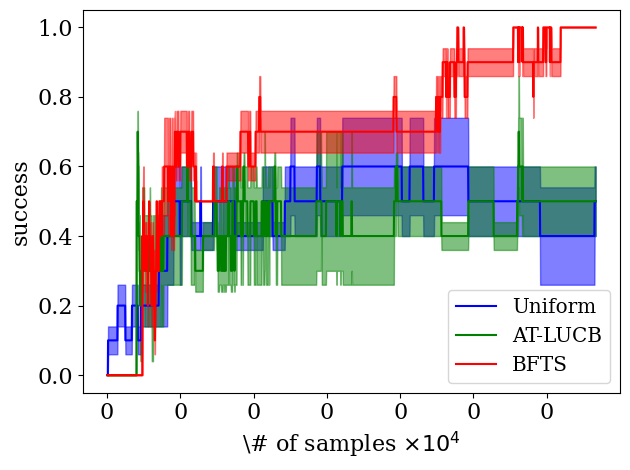

In [6]:
algos = ["uniform", "atlucb", "bfts"]
merge(algos, 2 * time, replicates, dir_, stat)
plot(algos, 2 * time, dir_, stat, None, None, dir_ + "/out.png")